In [1]:
import os
import dotenv
from pprint import pprint as print
import numpy as np
import pandas as pd
from functools import reduce
from gensim.models.fasttext import FastText, KeyedVectors
from corpus_prep_utils import dataset_names, data_step_names, filters, partition_rules, print_df
from database.storage_helper import StorageHelper
import corpus_prep_utils

# Reload the variables in your '.env' file (override the existing variables)
dotenv.load_dotenv("../.env", override=True)

input_data_root_path = os.environ.get("INPUT_DATA_ROOT_PATH")

def normalize_vector(vector):
  """Normalizes a numpy vector.

  Args:
    vector: A numpy array representing the vector.

  Returns:
    A numpy array representing the normalized vector.
  """
  norm = np.linalg.norm(vector)
  if norm == 0: 
    return vector  # Avoid division by zero
  return vector / norm

  # Calculate distances
def euclidean_distance(vector1, vector2):
  """Calculates the Euclidean distance between two numpy vectors.

  Args:
    vector1: The first numpy array.
    vector2: The second numpy array.

  Returns:
    The Euclidean distance between the vectors.
  """
  return np.linalg.norm(vector1 - vector2)

def cosine_similarity(vector1, vector2):
  """Calculates the cosine similarity between two numpy vectors.

  Args:
    vector1: The first numpy array.
    vector2: The second numpy array.

  Returns:
    The cosine similarity between the vectors.
  """
  dot_product = np.dot(vector1, vector2)
  norm_v1 = np.linalg.norm(vector1)
  norm_v2 = np.linalg.norm(vector2)
  return dot_product / (norm_v1 * norm_v2)

def get_vector(word, model):
    return model.wv[word]

def get_vector_for_partition(bioword_partition, model):
    #bioword_partition_vectors = map(lambda word : get_vector(word, model), bioword_partition)
    #bioword_partition_vector = reduce(lambda x, y: x + y, bioword_partition_vectors)
    #v1 = bioword_partition_vector / np.linalg.norm(bioword_partition_vector)
    #v2 = bioword_partition_vector / len(bioword_partition)
    v3 = np.zeros(100, dtype=np.float64)
    for i in range(1, len(bioword_partition)):
        v3 += model.wv[bioword_partition[i]]
    #print(bioword_partition_vector)
    #print(v3)
    v3 = v3 / len(bioword_partition)
    #print(np.linalg.norm(v1))
    #print(np.linalg.norm(v2))
    #print(np.linalg.norm(v3))
    return v3

/home/mgiordano/tesis/thesis_exp/.env


In [2]:
dataset = dataset_names.TEST_GROUP
#timestamp = "20241030_11_14_21"
timestamp = "20241029_15_41_02"
filter_name = filters.MR_FILTER_NONE.name
partition_rule_name = partition_rules.PARTITION_RULE_USE_ALL["name"]
model_path = corpus_prep_utils.get_model_path_by_run(input_data_root_path, dataset, timestamp, filter_name, partition_rule_name)
model = FastText.load(model_path)

In [4]:
corpus_file_iterator = corpus_prep_utils.get_corpus_file_iterator_from_run(input_data_root_path, dataset, timestamp, filter_name, partition_rule_name, False)
corpus_path = corpus_prep_utils.create_or_load_joined_corpus_file(corpus_file_iterator)



File /home/mgiordano/tesis/proteins_db/processed_datasets/testGroupDataset/20241029/20241029_15_41_02-testGroupDataset-filter_none-partition_use_all-s3_corpus_for_eval_000000000000.gz already exists. Skipping download.


In [13]:
df = pd.read_csv(corpus_path, encoding='utf-8')
print(df.head())

  sequence_family_name sequence_family_type           sequence_name  \
0             Collagen             fibrilar  UniRef90_UPI0006C80994   
1             Collagen             fibrilar  UniRef90_UPI000561A129   
2             Collagen             fibrilar         UniRef90_A3Z8E2   
3             Collagen             fibrilar  UniRef90_UPI0003F68BBA   
4             Collagen             fibrilar  UniRef90_UPI0005CC5B15   

                                            sequence  \
0  MNDNMCNNSCNNSCNNKCTWCPRCRCCPPVIVNCPTGVTGPAGPTG...   
1  MTDSSPEPRDPWAPLERPAVELGKPQGAQGKPGVSGPPSVHDQPTL...   
2  MGSWSSTGSIRGPEGPAGPQGSPGVQGSQGPAGPQGQQGPAGLQGP...   
3  MKKNIRNFFILLFALVLASLQPMYAYAAEDVVIEENKVRVSLLGKY...   
4  FPGFPGPKGVAGEPGPRGGPGPEGNQGQRGVSGSPGTVGQKGENGY...   

                                      word_partition  
0  MND MN M N ND NDN D DN DNM N NMC NM M MC MCN C...  
1  MTD MTDS MT M TD TDS T TDSS DSS DS DSSP D SSPE...  
2  M MGS MGSW MG G GSWS GS GSW SW S SWS WS WSS W ...  
3  MK MKK M KKNI

In [14]:
df["bio_vector"] = df["word_partition"].astype(str).apply(get_vector_for_partition, args=(model,))
print(df.head())

  sequence_family_name sequence_family_type           sequence_name  \
0             Collagen             fibrilar  UniRef90_UPI0006C80994   
1             Collagen             fibrilar  UniRef90_UPI000561A129   
2             Collagen             fibrilar         UniRef90_A3Z8E2   
3             Collagen             fibrilar  UniRef90_UPI0003F68BBA   
4             Collagen             fibrilar  UniRef90_UPI0005CC5B15   

                                            sequence  \
0  MNDNMCNNSCNNSCNNKCTWCPRCRCCPPVIVNCPTGVTGPAGPTG...   
1  MTDSSPEPRDPWAPLERPAVELGKPQGAQGKPGVSGPPSVHDQPTL...   
2  MGSWSSTGSIRGPEGPAGPQGSPGVQGSQGPAGPQGQQGPAGLQGP...   
3  MKKNIRNFFILLFALVLASLQPMYAYAAEDVVIEENKVRVSLLGKY...   
4  FPGFPGPKGVAGEPGPRGGPGPEGNQGQRGVSGSPGTVGQKGENGY...   

                                      word_partition  \
0  MND MN M N ND NDN D DN DNM N NMC NM M MC MCN C...   
1  MTD MTDS MT M TD TDS T TDSS DSS DS DSSP D SSPE...   
2  M MGS MGSW MG G GSWS GS GSW SW S SWS WS WSS W ...   
3  MK MKK M 

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Initialize t-SNE
tsne = TSNE(n_components=2, random_state=42, method='exact', perplexity=5, max_iter=5000)  # n_components=2 for 2D

# Apply t-SNE to reduce dimensionality
reduced_vectors = tsne.fit_transform(np.array(df["bio_vector"].to_list()))
df[['reduced_vector_d1', 'reduced_vector_d2']] = reduced_vectors

/home/mgiordano/tesis/thesis_exp/venv/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [9]:
print(df.head())

  sequence_family_name sequence_family_type           sequence_name  \
0             Collagen             fibrilar  UniRef90_UPI0006C80994   
1             Collagen             fibrilar  UniRef90_UPI000561A129   
2             Collagen             fibrilar         UniRef90_A3Z8E2   
3             Collagen             fibrilar  UniRef90_UPI0003F68BBA   
4             Collagen             fibrilar  UniRef90_UPI0005CC5B15   

                                            sequence  \
0  MNDNMCNNSCNNSCNNKCTWCPRCRCCPPVIVNCPTGVTGPAGPTG...   
1  MTDSSPEPRDPWAPLERPAVELGKPQGAQGKPGVSGPPSVHDQPTL...   
2  MGSWSSTGSIRGPEGPAGPQGSPGVQGSQGPAGPQGQQGPAGLQGP...   
3  MKKNIRNFFILLFALVLASLQPMYAYAAEDVVIEENKVRVSLLGKY...   
4  FPGFPGPKGVAGEPGPRGGPGPEGNQGQRGVSGSPGTVGQKGENGY...   

                                      word_partition  \
0  MND MN M N ND NDN D DN DNM N NMC NM M MC MCN C...   
1  MTD MTDS MT M TD TDS T TDSS DSS DS DSSP D SSPE...   
2  M MGS MGSW MG G GSWS GS GSW SW S SWS WS WSS W ...   
3  MK MKK M 

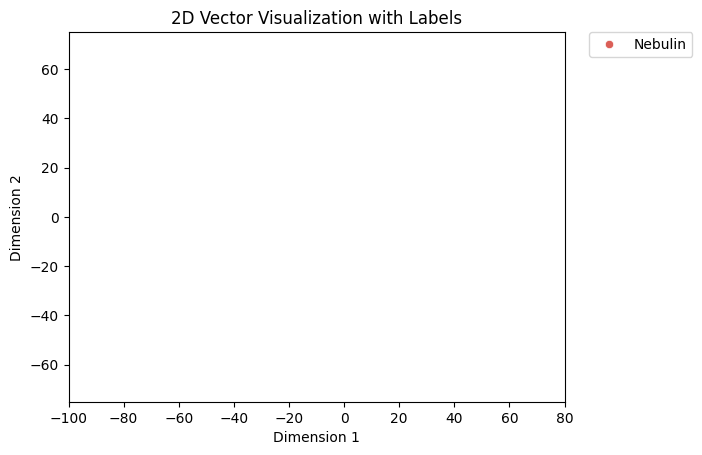

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

label = 'sequence_family_name'
filter_value = "Nebulin"
fdf = df[df[label]==filter_value]
# Create the scatter plot
sns.scatterplot(x='reduced_vector_d1', y='reduced_vector_d2', hue=label, data=df, palette='hls')

# Add labels and title
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("2D Vector Visualization with Labels")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.xlim(-100,80)
plt.ylim(-75,75)
# Show the plot
plt.show()

In [8]:
bioword_partition = ["MND", "MN", "M", "N", "ND", "NDN", "D", "DN", "DNM", "N", "NMC", 
             "NM", "M", "MC", "MCN", "C", "CNNSCNN", "CN", "CNN", "CNNS", "N", 
             "NN", "NNSC", "NNS", "N", "NS", "NSCN", "NSC", "S", "SCN", "SC", 
             "SCNN", "C", "CNNSCNN", "CN", "CNN", "CNNS", "N", "NN", "NNSC", 
             "NNS", "N", "NS", "NSCN", "NSC", "S", "SCN", "SC", "SCNN", "C", 
             "CN", "CNN", "CNNK", "N", "NN", "NNK", "N", "NKC", "NK", "K", 
             "KCT", "KC", "C", "CT", "CTW", "CTWC", "TW", "TWC", "T", "WCPRC", 
             "W", "WCP", "WC", "C", "CPR", "CP", "P", "PR", "PRC", "RCR", "RC", 
             "R", "C", "CR", "CRC", "RC", "RCC", "R", "C", "CCP", "CC", "C", 
             "CP", "CPPV", "CPP", "P", "PP", "PPVI", "PPV", "P", "PVIV", "PVI", 
             "PV", "V", "VIVN", "VIVNC", "VIV", "VI", "IVN", "IV", "I", "V", 
             "VNCP", "VNC", "VN", "VNCPT", "N", "NCPT", "NCP", "NC", "C", "CP", 
             "CPTG", "CPT", "CPTGV", "P", "PT", "PTG", "PTGV", "T", "TG", "TGV", 
             "TGVTG", "TGVT", "GV", "G", "GVTG", "GVT", "V", "VTG", "VT", "VTGP", 
             "VTGPA", "T", "TG", "TGPAG", "TGPA", "TGP", "G", "GPA", "GPAGP", 
             "GPAG", "GP", "P", "PAG", "PA", "PAGP", "AGPT", "AG", "A", "AGP", 
             "G", "GP", "GPTG", "GPT", "GPTGP", "P", "PT", "PTG", "PTGP", "T", 
             "TG", "TGP", "TGPM", "TGPMG", "G", "GP", "GPM", "GPMG", "P", "PMG", 
             "PM", "M", "MG", "MGC", "G", "GC", "GCP", "GCPG", "C", "CP", "CPGP", 
             "CPG", "P", "PGP", "PGPR", "PG", "PGPRG", "G", "GP", "GPRG", "GPR", 
             "P", "PR", "PRG", "PRGA", "R", "RGAT", "RG", "RGA", "G", "GATGP", 
             "GAT", "GA", "GATG", "A", "ATGP", "AT", "ATG", "T", "TG", "TGP", 
             "TGPM", "TGPMG", "G", "GP", "GPM", "GPMG", "P", "PMG", "PM", "M", 
             "MG", "MGP", "G", "GP", "GPM", "GPMG", "GPMGY", "P", "PMG", "PM", 
             "M", "MGY", "G", "GYPGK", "GYP", "GYPG", "GY", "YPG", "Y", "YP", 
             "YPGK", "P", "PG", "PGKT", "PGK", "G", "GK", "GKTG", "GKT", "K", 
             "KTGAT", "KT", "KTG", "KTGA", "T", "TG", "TGAT", "TGATG", "TGA", 
             "G", "GATGP", "GAT", "GA", "GATG", "A", "ATGP", "AT", "ATG", "T", 
             "TG", "TGP", "TGPTG", "TGPTGA", "TGPT", "G", "GP", "GPTG", "GPT", 
             "P", "PT", "PTG", "PTGAT", "PTGA", "T", "TG", "TGAT", "TGATG", 
             "TGA", "G", "GAT", "GA", "GATG", "GATGQ", "A", "AT", "ATG", "ATGQEV", 
             "ATGQ", "T", "TG", "TGQ", "TGQE", "G", "GQE", "GQEV", "GQ", "QEV", 
             "QE", "Q", "QEVV", "EVV", "EVVL", "EV", "E", "V", "VVL", "VVLD", 
             "VV", "V", "VLDQ", "VL", "VLD", "L", "LDQ", "LD", "LDQEV", "LDQE", 
             "D", "DQEV", "DQ", "DQE", "QEV", "QE", "Q", "EV", "E", "V"]

get_vector_for_partition(model, bioword_partition)

array([-36326.29110225, -13318.68203825,   7749.36719015,  18760.36400967,
        -3029.379783  ,  -3138.21590251, -16202.10224617,  32532.61171585,
         4449.1345894 ,  -2618.52321168,  16697.27126908,  15638.73303568,
       -10112.08940959,   1843.09651864, -11572.58202095, -11266.75751173,
        11389.03909564, -13093.4495374 ,  28295.65671486,   6165.93212624,
        -5609.74424028, -19616.29764271,  23473.7717784 , -25914.39644808,
          565.25619549, -33698.00743496,   7165.67888069,  -9897.607885  ,
        20183.82368702,  33565.2507751 ,  -9607.48631042, -25328.67157456,
        43670.8708117 ,  26289.85808396,  29248.19485915,  51699.63978457,
       -19536.13773479,  35664.27464592, -23129.99831986,   7977.78896785,
        -6980.55364452, -14926.5761224 ,  50783.61349231,  26801.8637805 ,
        -3289.81910494, -22652.36374474,   7420.83010394,  15495.9305768 ,
       -14127.9634819 ,  14693.44823909,   -354.01703274, -47795.8335197 ,
       -11957.68351221, -

In [5]:
#model.wv.most_similar("NNSC")
model.wv["NNSC"]

array([  99.897575 ,   -0.7501249,  161.60553  ,   62.111263 ,
       -107.68044  ,  107.44453  , -100.1533   ,  -12.231828 ,
        -12.497793 ,  -77.28887  ,  -37.46371  ,  -60.886215 ,
       -152.92209  ,   54.151627 ,   -8.727021 ,  129.1065   ,
        -36.58401  ,   43.37036  ,  225.02979  ,   92.69162  ,
        -72.76957  ,  199.71971  ,  -11.437565 ,  -28.67107  ,
         45.566673 ,    8.997268 , -139.21173  ,   63.31879  ,
        145.22743  ,  119.99709  , -200.9088   ,  127.82464  ,
         97.48038  ,  152.15503  ,   -7.2347593,  -70.9874   ,
        121.69223  , -167.6571   , -184.51695  , -154.99615  ,
         26.856287 ,  -43.28205  ,   65.603485 ,   98.18843  ,
        158.03963  ,   -6.5182476,  136.37773  ,   18.064207 ,
         -3.6219046,   39.844814 ,   59.705837 ,  -63.299156 ,
        121.12251  ,  -43.695152 ,   93.29185  ,  -62.31577  ,
       -262.85812  ,   73.30676  ,  -59.99435  ,   87.9391   ,
         54.229404 , -101.23369  ,   85.34487  , -156.5

In [ ]:
word_list = ["MND", "MN", "M", "N", "ND", "NDN", "D", "DN", "DNM", "N", "NMC", 
             "NM", "M", "MC", "MCN", "C", "CNNSCNN", "CN", "CNN", "CNNS", "N", 
             "NN", "NNSC", "NNS", "N", "NS", "NSCN", "NSC", "S", "SCN", "SC", 
             "SCNN", "C", "CNNSCNN", "CN", "CNN", "CNNS", "N", "NN", "NNSC", 
             "NNS", "N", "NS", "NSCN", "NSC", "S", "SCN", "SC", "SCNN", "C", 
             "CN", "CNN", "CNNK", "N", "NN", "NNK", "N", "NKC", "NK", "K", 
             "KCT", "KC", "C", "CT", "CTW", "CTWC", "TW", "TWC", "T", "WCPRC", 
             "W", "WCP", "WC", "C", "CPR", "CP", "P", "PR", "PRC", "RCR", "RC", 
             "R", "C", "CR", "CRC", "RC", "RCC", "R", "C", "CCP", "CC", "C", 
             "CP", "CPPV", "CPP", "P", "PP", "PPVI", "PPV", "P", "PVIV", "PVI", 
             "PV", "V", "VIVN", "VIVNC", "VIV", "VI", "IVN", "IV", "I", "V", 
             "VNCP", "VNC", "VN", "VNCPT", "N", "NCPT", "NCP", "NC", "C", "CP", 
             "CPTG", "CPT", "CPTGV", "P", "PT", "PTG", "PTGV", "T", "TG", "TGV", 
             "TGVTG", "TGVT", "GV", "G", "GVTG", "GVT", "V", "VTG", "VT", "VTGP", 
             "VTGPA", "T", "TG", "TGPAG", "TGPA", "TGP", "G", "GPA", "GPAGP", 
             "GPAG", "GP", "P", "PAG", "PA", "PAGP", "AGPT", "AG", "A", "AGP", 
             "G", "GP", "GPTG", "GPT", "GPTGP", "P", "PT", "PTG", "PTGP", "T", 
             "TG", "TGP", "TGPM", "TGPMG", "G", "GP", "GPM", "GPMG", "P", "PMG", 
             "PM", "M", "MG", "MGC", "G", "GC", "GCP", "GCPG", "C", "CP", "CPGP", 
             "CPG", "P", "PGP", "PGPR", "PG", "PGPRG", "G", "GP", "GPRG", "GPR", 
             "P", "PR", "PRG", "PRGA", "R", "RGAT", "RG", "RGA", "G", "GATGP", 
             "GAT", "GA", "GATG", "A", "ATGP", "AT", "ATG", "T", "TG", "TGP", 
             "TGPM", "TGPMG", "G", "GP", "GPM", "GPMG", "P", "PMG", "PM", "M", 
             "MG", "MGP", "G", "GP", "GPM", "GPMG", "GPMGY", "P", "PMG", "PM", 
             "M", "MGY", "G", "GYPGK", "GYP", "GYPG", "GY", "YPG", "Y", "YP", 
             "YPGK", "P", "PG", "PGKT", "PGK", "G", "GK", "GKTG", "GKT", "K", 
             "KTGAT", "KT", "KTG", "KTGA", "T", "TG", "TGAT", "TGATG", "TGA", 
             "G", "GATGP", "GAT", "GA", "GATG", "A", "ATGP", "AT", "ATG", "T", 
             "TG", "TGP", "TGPTG", "TGPTGA", "TGPT", "G", "GP", "GPTG", "GPT", 
             "P", "PT", "PTG", "PTGAT", "PTGA", "T", "TG", "TGAT", "TGATG", 
             "TGA", "G", "GAT", "GA", "GATG", "GATGQ", "A", "AT", "ATG", "ATGQEV", 
             "ATGQ", "T", "TG", "TGQ", "TGQE", "G", "GQE", "GQEV", "GQ", "QEV", 
             "QE", "Q", "QEVV", "EVV", "EVVL", "EV", "E", "V", "VVL", "VVLD", 
             "VV", "V", "VLDQ", "VL", "VLD", "L", "LDQ", "LD", "LDQEV", "LDQE", 
             "D", "DQEV", "DQ", "DQE", "QEV", "QE", "Q", "EV", "E", "V"]

protein = "MNDNMCNNSCNNSCNNKCTWCPRCRCCPPVIVNCPTGVTGPAGPTGPMGCPGPRGATGPMGPMGYPGKTGATGPTGATGQEVVLDQEV"



mapped_vectors = map(get_vector, word_list)
protein_vector = reduce(lambda x, y: x + y, mapped_vectors)
print(protein_vector)
estimated_vector = model.wv[protein]
print(estimated_vector)


array([-1.24240097e+02,  5.33222580e+00,  4.20243286e+02, -2.53278870e+02,
       -4.18920959e+02,  2.33539490e+02, -2.87695984e+02,  1.33713486e+02,
        8.13767548e+01, -2.08415421e+02,  2.74025482e+02, -5.64492874e+01,
       -1.50059525e+02, -9.69209061e+01,  8.77655258e+01, -3.75407837e+02,
        1.11921196e+02, -2.32642120e+02,  2.60416229e+02, -2.01039505e+02,
       -4.78986877e+02, -2.30500076e+02, -1.75236282e+02, -4.89237610e+02,
       -2.14543285e+01, -3.81962311e+02,  6.84888458e+01,  2.22862442e+02,
       -9.49343719e+01,  4.79933858e-01,  2.25807770e+02,  1.26625504e+02,
       -1.81909485e+02,  7.23908615e+01,  5.80154541e+02,  2.27350937e+02,
       -3.30667542e+02,  1.19018440e+02, -1.87081619e+02, -2.78131592e+02,
       -2.52466690e+02, -5.47369934e+02,  3.94841949e+02,  1.19354156e+02,
        5.98624695e+02,  1.90460342e+02, -5.24947205e+02,  1.07508507e+01,
        5.11681290e+01, -2.46088821e+02,  2.60147064e+02, -3.03916168e+02,
       -2.99523254e+02,  